# CVAI Übung: Convolution


### libraries

In [1]:
import numpy as np
import matplotlib.pyplot as pl
import cv2 as cv

path = '/exchange/cvai/images/'

## read greylevel image

(1264, 1741)


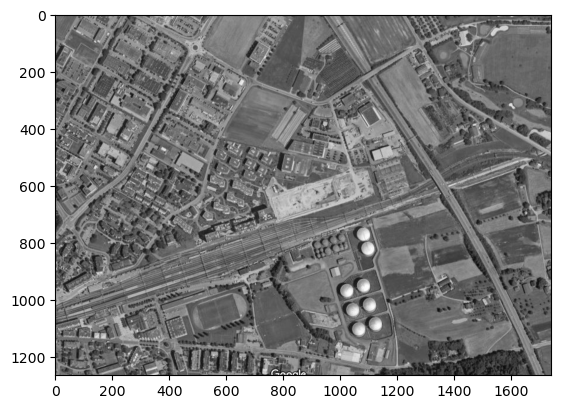

In [2]:
img = cv.cvtColor (cv.imread (path + 'air_image.png'), cv.COLOR_BGR2GRAY)
print (img.shape)
pl.imshow (img, cmap = 'gray')

## read pattern to recognize

(111, 93)


libpng warning: iCCP: profile 'ICC profile': 'GRAY': Gray color space not permitted on RGB PNG


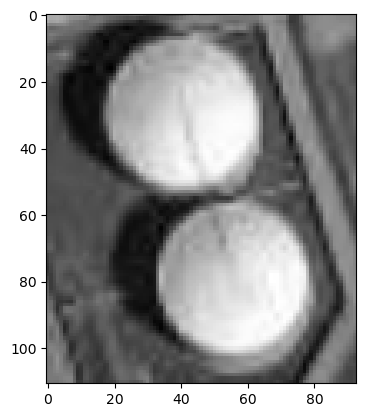

In [3]:
mask = cv.cvtColor (cv.imread (path + 'air_mask.png'), cv.COLOR_BGR2GRAY)
print (mask.shape)
pl.imshow (mask, cmap = 'gray')

## Exercise 1

Try to localize mask in image using correlation.

-0.483438640832901 0.9097429513931274 (1218, 795) (1042, 741)


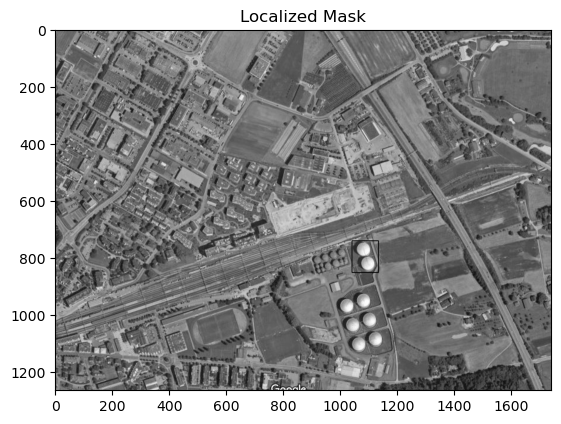

In [7]:
result = cv.matchTemplate(img, mask, cv.TM_CCOEFF_NORMED)

# Find the location with the highest matching score
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(result)
print(min_val, max_val, min_loc, max_loc)

# For TM_CCOEFF_NORMED, the best match is at max_loc
top_left = max_loc
h, w = mask.shape
bottom_right = (top_left[0] + w, top_left[1] + h)

# Draw a rectangle around the detected region
cv.rectangle(img, top_left, bottom_right, (0, 255, 0), 2)

# Display the result
pl.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
pl.title("Localized Mask")
pl.show()


As result you will localize the mask in the near of the right position, but not exactly.
Please think about the reason for this fail.

## Exercise 2

Try some operators for edge detection. Apply these operators to the image before repeating 
exercise 1 with thee preprocessed images. Is the result better now? Think about the reasons.

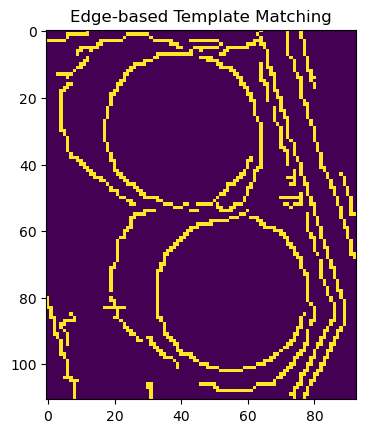

In [12]:
edges_mask = cv.Canny(mask, 100, 200)
edges_image = cv.Canny(img, 100, 200)

pl.imshow(edges_mask)
# Perform template matching on the edge-detected images
result = cv.matchTemplate(edges_image, edges_mask, cv.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(result)

# Determine the top-left corner of the best match
top_left = max_loc
h, w = edges_mask.shape
bottom_right = (top_left[0] + w, top_left[1] + h)

# Convert the original image to color for visualization and draw a rectangle
image_color = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
cv.rectangle(image_color, top_left, bottom_right, (0, 255, 0), 2)

# Display the result
#pl.imshow(cv.cvtColor(image_color, cv.COLOR_BGR2RGB))
pl.title("Edge-based Template Matching")
pl.show()